In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import warnings

from visions.backends.python.types import time

# from ydata_profiling import ProfileReport
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score
)

from sklearn.datasets import load_breast_cancer


In [2]:
df=pd.read_csv("C:/Users/yahia/PycharmProjects/JupyterProject3/data/breast-cancer.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [4]:
print(df.describe())
print(df.isnull().sum())

                 id  radius_mean  texture_mean  perimeter_mean    area_mean  \
count  5.690000e+02   569.000000    569.000000      569.000000   569.000000   
mean   3.037183e+07    14.127292     19.289649       91.969033   654.889104   
std    1.250206e+08     3.524049      4.301036       24.298981   351.914129   
min    8.670000e+03     6.981000      9.710000       43.790000   143.500000   
25%    8.692180e+05    11.700000     16.170000       75.170000   420.300000   
50%    9.060240e+05    13.370000     18.840000       86.240000   551.100000   
75%    8.813129e+06    15.780000     21.800000      104.100000   782.700000   
max    9.113205e+08    28.110000     39.280000      188.500000  2501.000000   

       smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.014064          0.052813     

In [5]:
print(df.head(20))

          id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0     842302         M        17.99         10.38          122.80     1001.0   
1     842517         M        20.57         17.77          132.90     1326.0   
2   84300903         M        19.69         21.25          130.00     1203.0   
3   84348301         M        11.42         20.38           77.58      386.1   
4   84358402         M        20.29         14.34          135.10     1297.0   
5     843786         M        12.45         15.70           82.57      477.1   
6     844359         M        18.25         19.98          119.60     1040.0   
7   84458202         M        13.71         20.83           90.20      577.9   
8     844981         M        13.00         21.82           87.50      519.8   
9   84501001         M        12.46         24.04           83.97      475.9   
10    845636         M        16.02         23.24          102.70      797.8   
11  84610002         M        15.78     

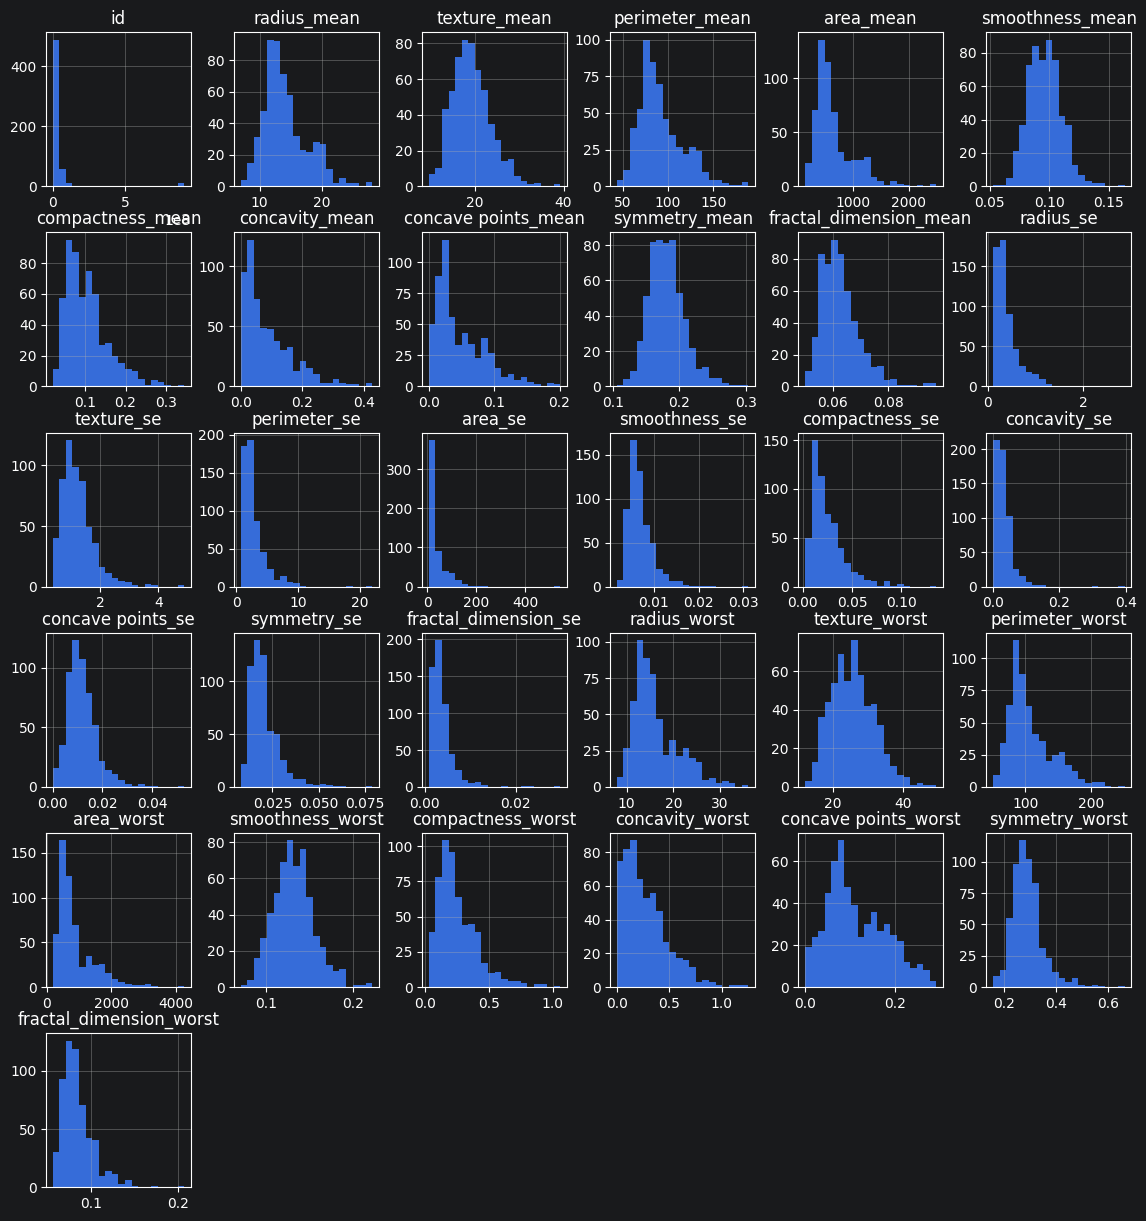

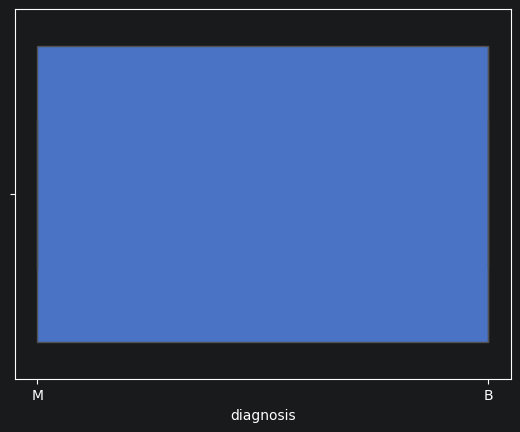

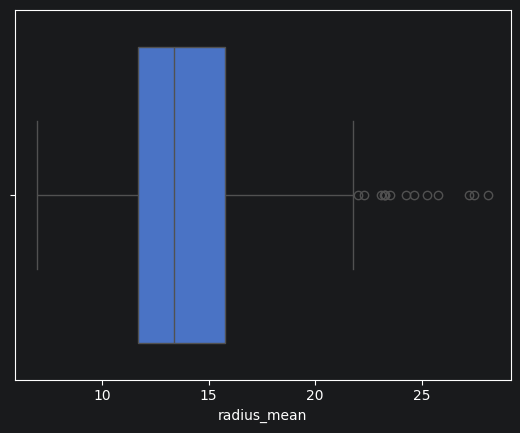

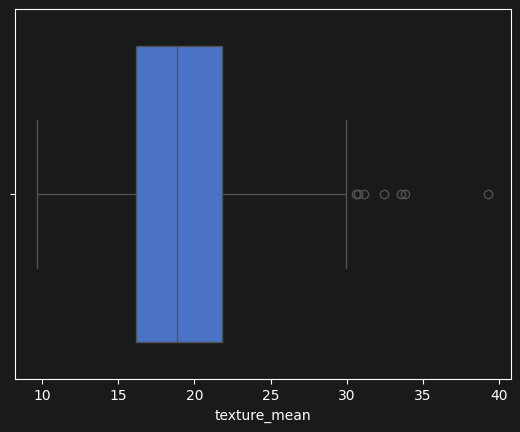

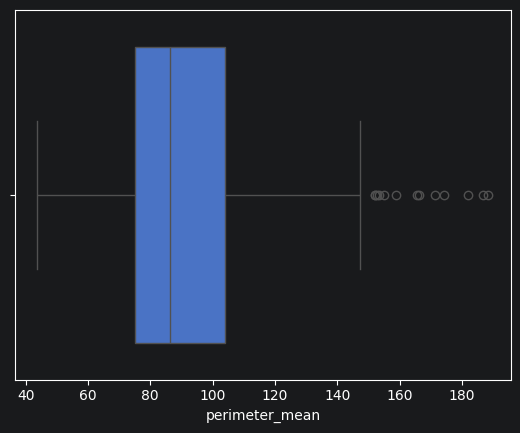

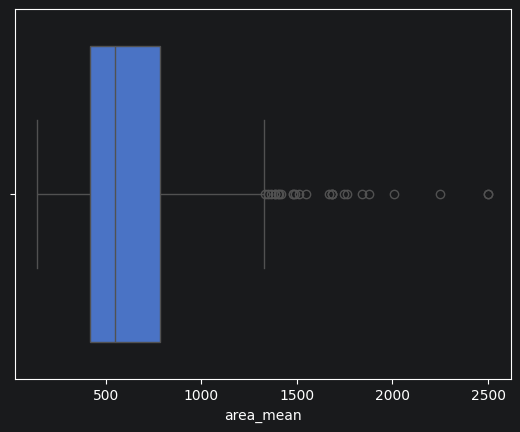

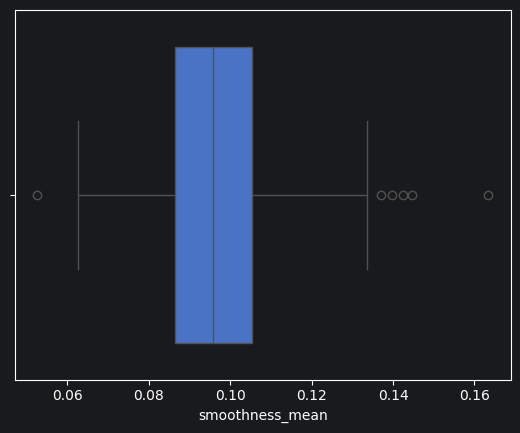

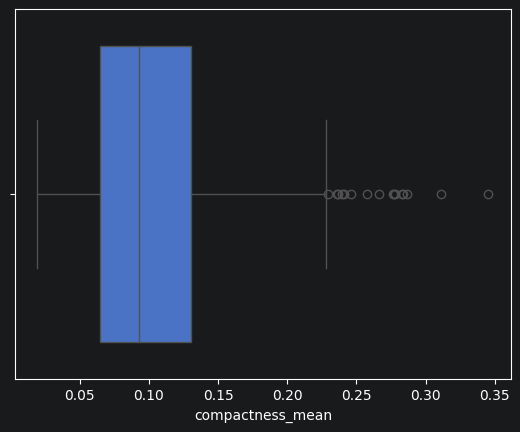

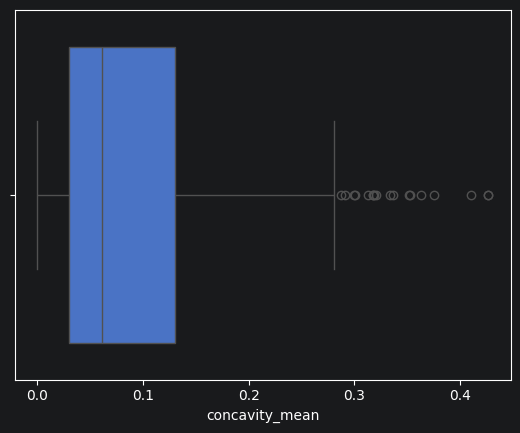

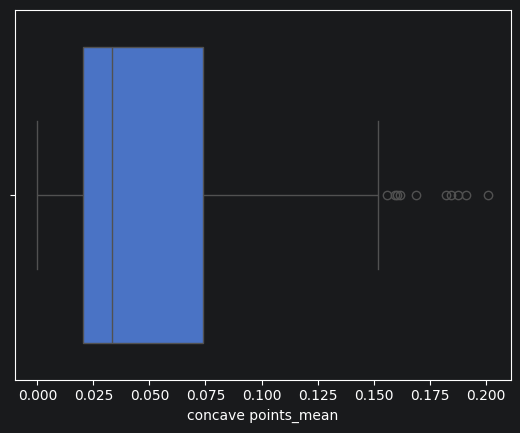

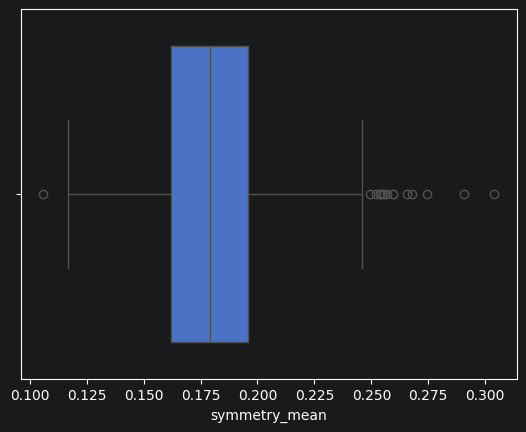

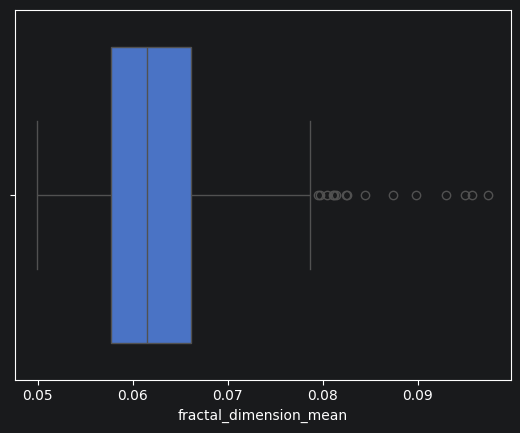

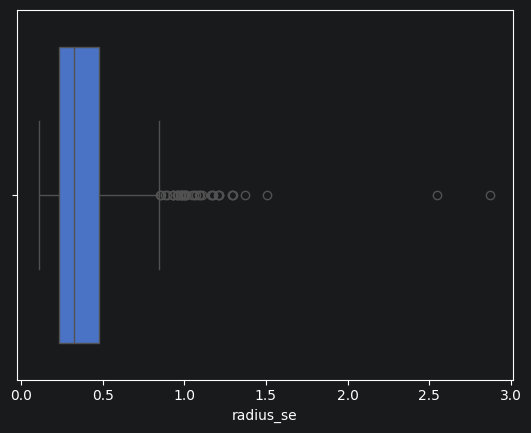

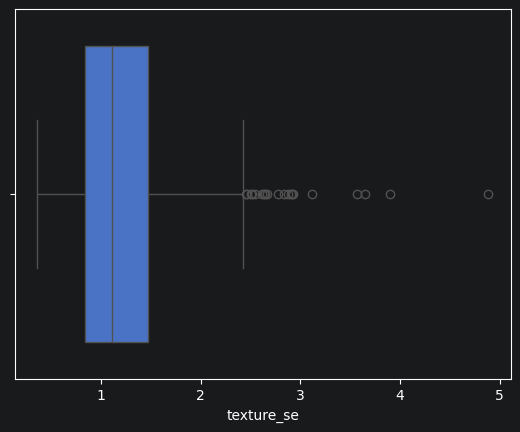

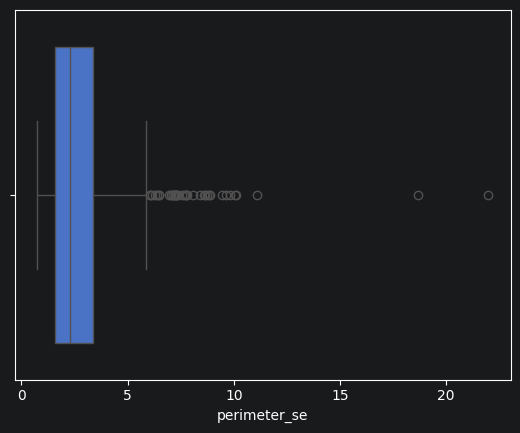

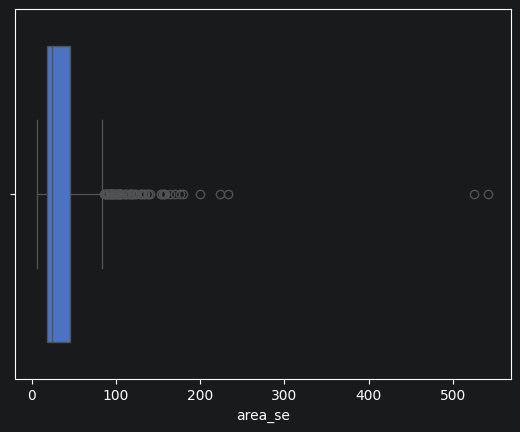

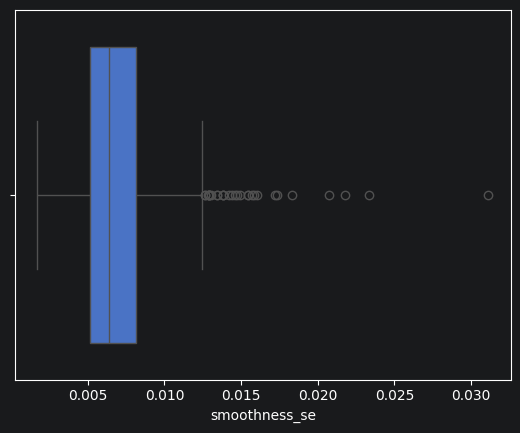

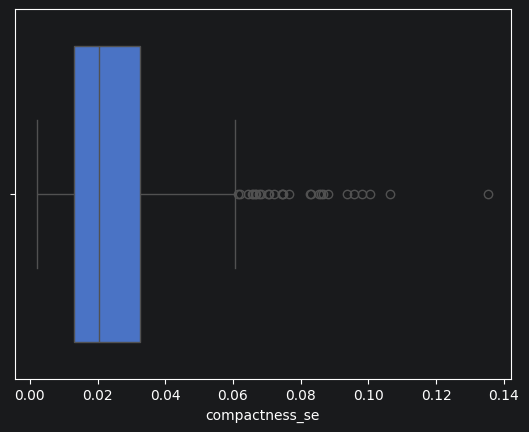

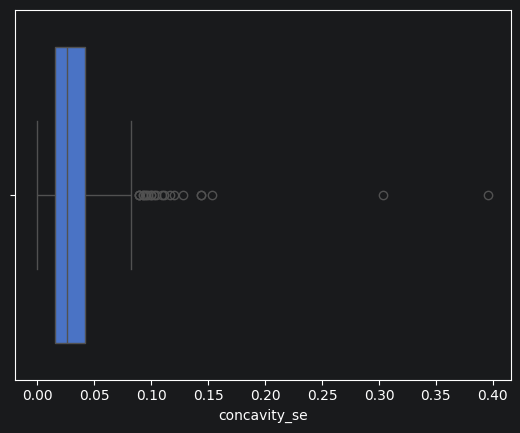

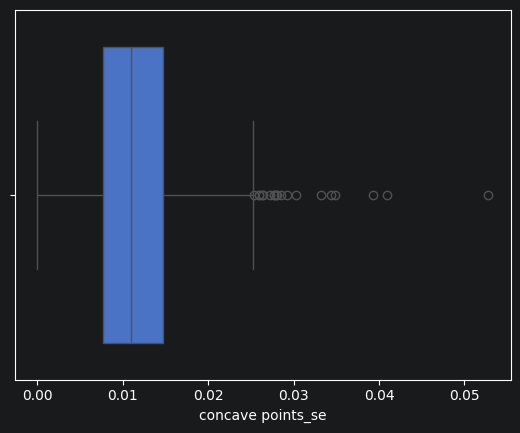

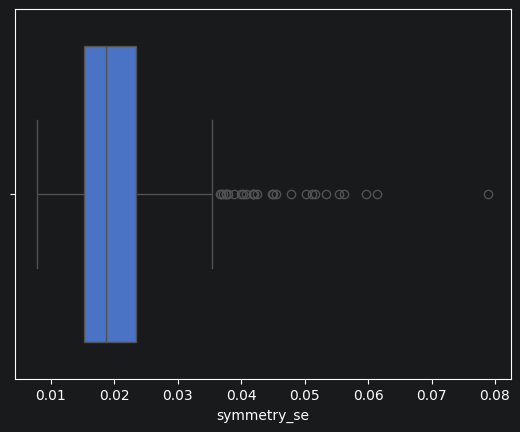

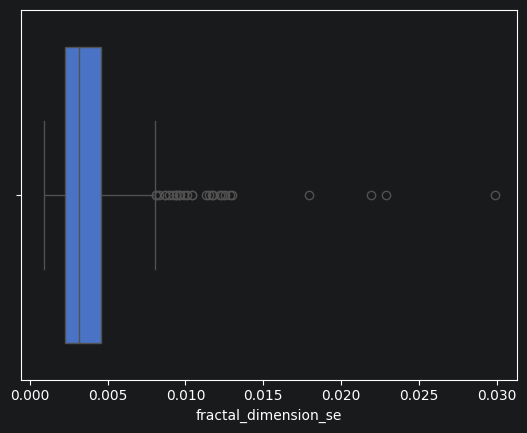

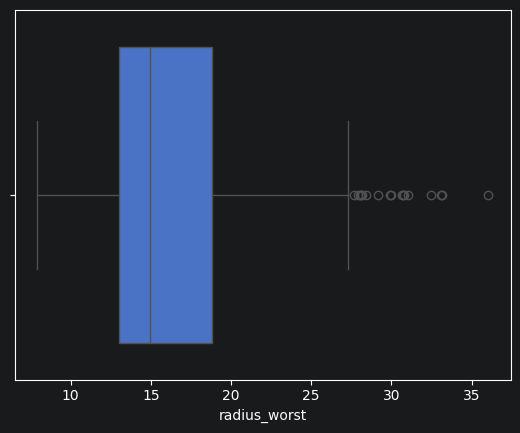

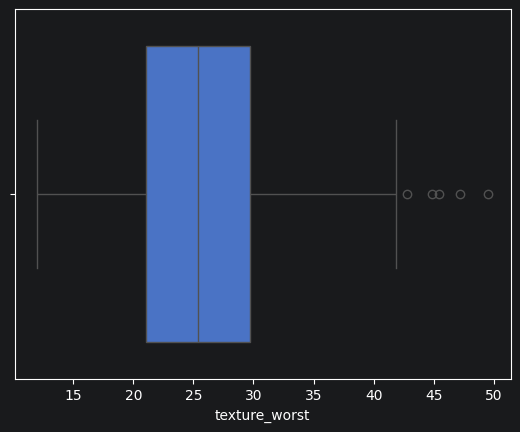

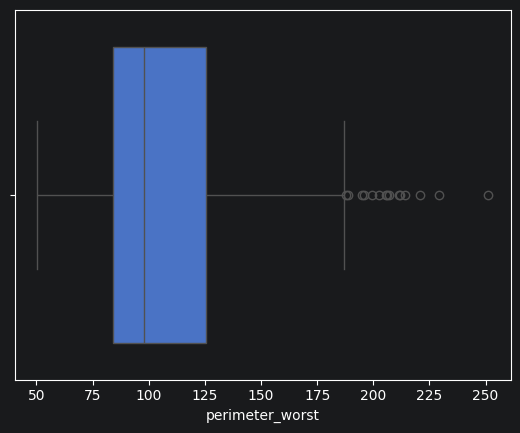

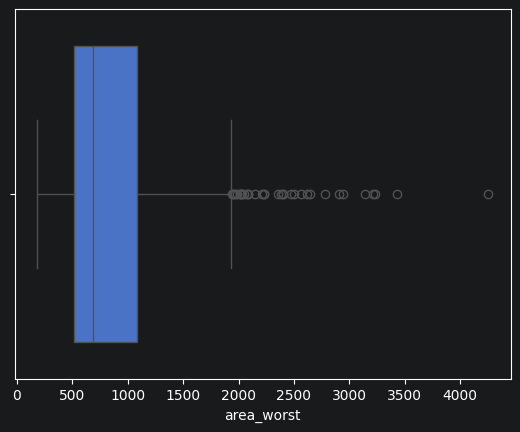

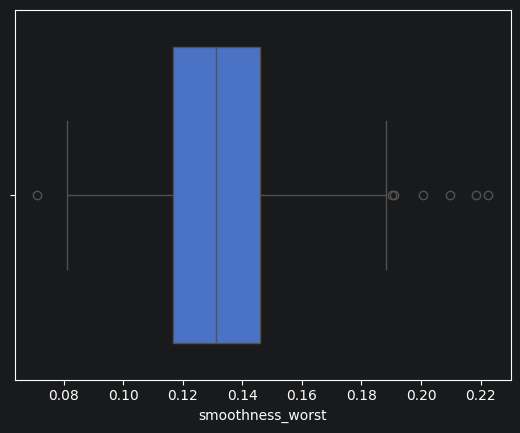

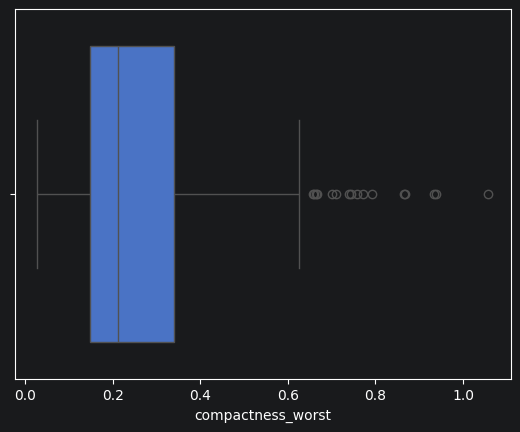

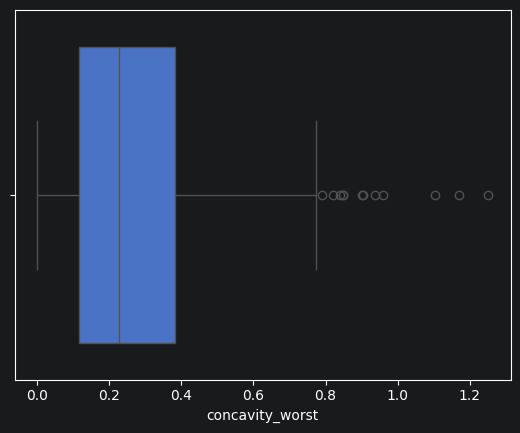

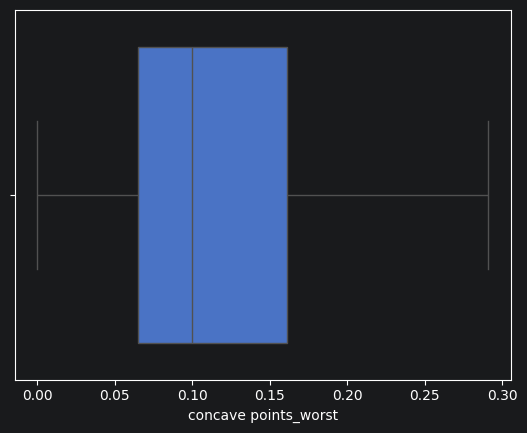

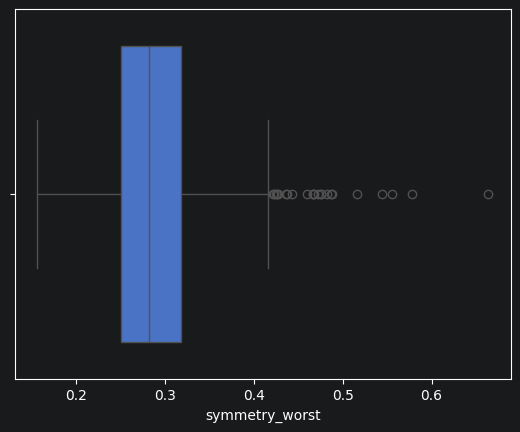

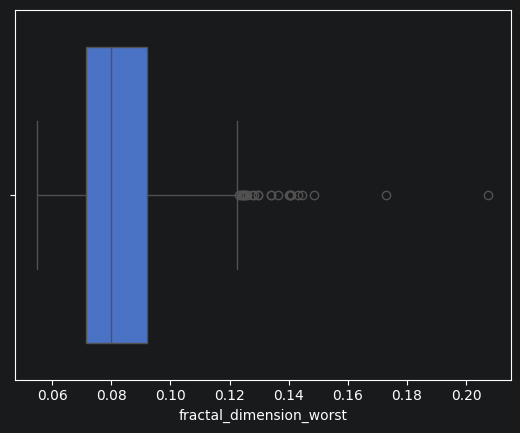

In [6]:
df.hist(figsize=(14,15), bins=20)
for col in df.columns:
    sns.boxplot(x=df[col]); plt.show()

In [7]:
df.drop(columns=['id'], inplace=True)

In [9]:
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


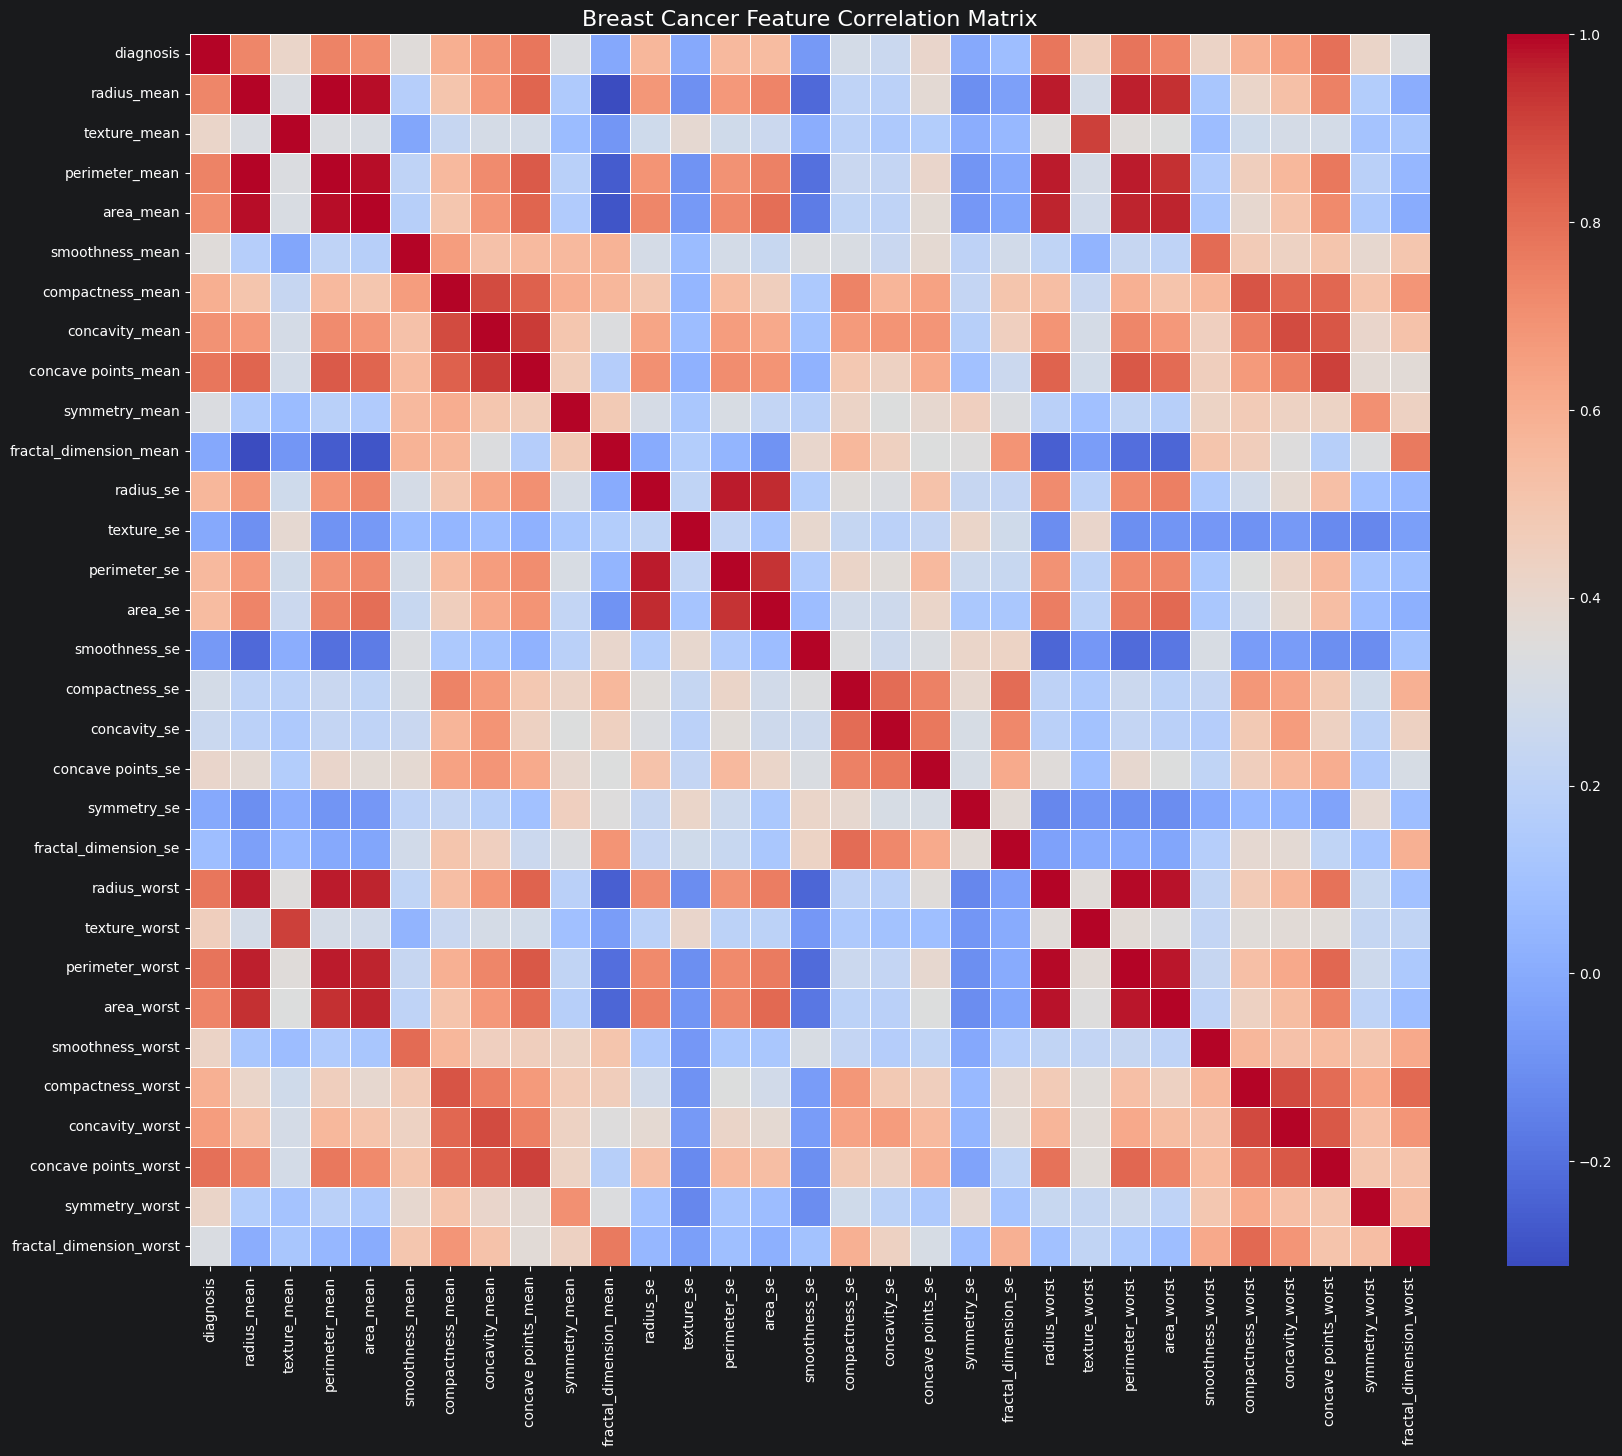

In [10]:
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

# Now run your correlation matrix normally
corr_matrix = df.corr()

plt.figure(figsize=(20, 16))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Breast Cancer Feature Correlation Matrix", fontsize=16)
plt.show()

In [11]:
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [12]:
print(df.head(20))

    diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0           1        17.99         10.38          122.80     1001.0   
1           1        20.57         17.77          132.90     1326.0   
2           1        19.69         21.25          130.00     1203.0   
3           1        11.42         20.38           77.58      386.1   
4           1        20.29         14.34          135.10     1297.0   
5           1        12.45         15.70           82.57      477.1   
6           1        18.25         19.98          119.60     1040.0   
7           1        13.71         20.83           90.20      577.9   
8           1        13.00         21.82           87.50      519.8   
9           1        12.46         24.04           83.97      475.9   
10          1        16.02         23.24          102.70      797.8   
11          1        15.78         17.89          103.60      781.0   
12          1        19.17         24.80          132.40     1123.0   
13    

In [16]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler

# 1. Separate features (X) and target label (y)
X = df.drop(columns=['diagnosis'])
y = df['diagnosis']

# 2. Split into Train (80%) and Test (20%) sets FIRST
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Feature Selection: Remove Collinear Features (Run on Train Data only)
corr_features = X_train_raw.corr().abs()
upper_tri = corr_features.where(np.triu(np.ones(corr_features.shape), k=1).astype(bool))
to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > 0.95)]

# Drop from both training and testing raw subsets
X_train_filtered = X_train_raw.drop(columns=to_drop)
X_test_filtered = X_test_raw.drop(columns=to_drop)

# 4. Feature Scaling (Using RobustScaler)
scaler = RobustScaler()

# Fit only on the training set, then transform both subsets
X_train_scaled = scaler.fit_transform(X_train_filtered)
X_test_scaled = scaler.transform(X_test_filtered)

# 5. Convert back to clean DataFrames for visibility
X_train_final = pd.DataFrame(X_train_scaled, columns=X_train_filtered.columns)
X_test_final = pd.DataFrame(X_test_scaled, columns=X_test_filtered.columns)

print(f"Dropped {len(to_drop)} collinear columns.")
print(f"Final training array shape: {X_train_final.shape}")


Dropped 7 collinear columns.
Final training array shape: (455, 23)


In [18]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# ==========================================
# 1. TRAIN & TUNE K-NEAREST NEIGHBORS (KNN)
# ==========================================
print("--- Training K-Nearest Neighbors ---")

# Define the model and parameter grid to search over
knn = KNeighborsClassifier()
knn_param_grid = {
    'n_neighbors':[3, 5, 7, 9, 11],  # Add this list of numbers
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}


# Perform Grid Search with 5-fold cross-validation
knn_grid = GridSearchCV(knn, knn_param_grid, cv=5, scoring='accuracy', n_jobs=-1)
knn_grid.fit(X_train_final, y_train)

# Predict using the best KNN model
best_knn = knn_grid.best_estimator_
knn_preds = best_knn.predict(X_test_final)

print(f"Best KNN Parameters: {knn_grid.best_params_}")
print(f"KNN Test Accuracy  : {accuracy_score(y_test, knn_preds):.4f}\n")











# ==========================================
# 2. TRAIN & TUNE SUPPORT VECTOR MACHINE (SVM)
# ==========================================
print("--- Training Support Vector Machine ---")

# Define the model and parameter grid to search over
svm = SVC(random_state=42)
svm_param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.01, 0.1, 1],
    'kernel': ['linear', 'rbf']
}

# Perform Grid Search with 5-fold cross-validation
svm_grid = GridSearchCV(svm, svm_param_grid, cv=5, scoring='accuracy', n_jobs=-1)
svm_grid.fit(X_train_final, y_train)

# Predict using the best SVM model
best_svm = svm_grid.best_estimator_
svm_preds = best_svm.predict(X_test_final)

print(f"Best SVM Parameters: {svm_grid.best_params_}")
print(f"SVM Test Accuracy  : {accuracy_score(y_test, svm_preds):.4f}\n")








print("--- Detailed Evaluation Reports ---")
print("\n[KNN Classification Report]")
print(classification_report(y_test, knn_preds, target_names=['Benign', 'Malignant']))

print("\n[SVM Classification Report]")
print(classification_report(y_test, svm_preds, target_names=['Benign', 'Malignant']))


--- Training K-Nearest Neighbors ---
Best KNN Parameters: {'metric': 'euclidean', 'n_neighbors': 9, 'weights': 'uniform'}
KNN Test Accuracy  : 0.9211

--- Training Support Vector Machine ---
Best SVM Parameters: {'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}
SVM Test Accuracy  : 0.9825

--- Detailed Evaluation Reports ---

[KNN Classification Report]
              precision    recall  f1-score   support

      Benign       0.91      0.97      0.94        72
   Malignant       0.95      0.83      0.89        42

    accuracy                           0.92       114
   macro avg       0.93      0.90      0.91       114
weighted avg       0.92      0.92      0.92       114


[SVM Classification Report]
              precision    recall  f1-score   support

      Benign       0.97      1.00      0.99        72
   Malignant       1.00      0.95      0.98        42

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98 

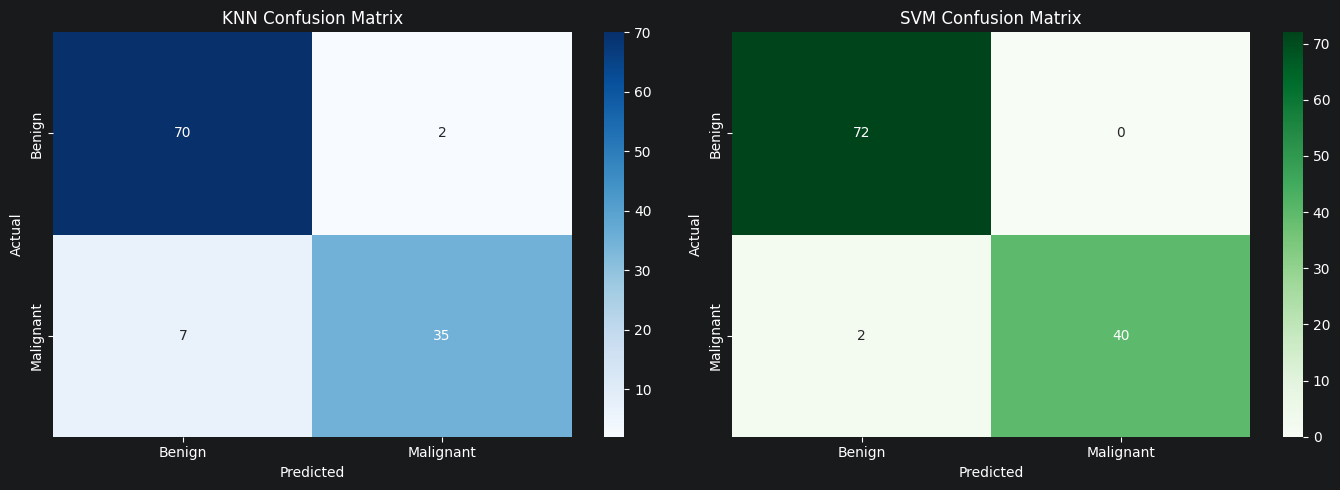

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot KNN Confusion Matrix
sns.heatmap(confusion_matrix(y_test, knn_preds), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'], ax=axes[0])
axes[0].set_title('KNN Confusion Matrix')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Plot SVM Confusion Matrix
sns.heatmap(confusion_matrix(y_test, svm_preds), annot=True, fmt='d', cmap='Greens',
            xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'], ax=axes[1])
axes[1].set_title('SVM Confusion Matrix')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.show()


In [23]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

# Initialize a dictionary to store our predictions for the final confusion matrix plot
model_predictions = {}

# ==========================================
# 1. TRAIN & TUNE LOGISTIC REGRESSION
# ==========================================
print("--- Training Logistic Regression ---")
log_reg = LogisticRegression(max_iter=10000, random_state=42)
lr_param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']  # Good solver for small datasets handling l1 and l2 penalties
}

lr_grid = GridSearchCV(log_reg, lr_param_grid, cv=5, scoring='accuracy', n_jobs=-1)
lr_grid.fit(X_train_final, y_train)
best_lr = lr_grid.best_estimator_
model_predictions['Logistic Regression'] = best_lr.predict(X_test_final)

print(f"Best LR Params  : {lr_grid.best_params_}")
print(f"LR Test Accuracy: {accuracy_score(y_test, model_predictions['Logistic Regression']):.4f}\n")


--- Training Logistic Regression ---
Best LR Params  : {'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}
LR Test Accuracy: 0.9825



In [25]:

# ==========================================
# 2. TRAIN & TUNE RANDOM FOREST
# ==========================================
print("--- Training Random Forest ---")
rf = RandomForestClassifier(random_state=42)
rf_param_grid = {
    'n_estimators':[3, 5, 7, 9, 11],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

rf_grid = GridSearchCV(rf, rf_param_grid, cv=5, scoring='accuracy', n_jobs=-1)
rf_grid.fit(X_train_final, y_train)
best_rf = rf_grid.best_estimator_
model_predictions['Random Forest'] = best_rf.predict(X_test_final)

print(f"Best RF Params  : {rf_grid.best_params_}")
print(f"RF Test Accuracy: {accuracy_score(y_test, model_predictions['Random Forest']):.4f}\n")


--- Training Random Forest ---
Best RF Params  : {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 11}
RF Test Accuracy: 0.9474



In [26]:

# ==========================================
# 3. TRAIN & TUNE GRADIENT BOOSTING
# ==========================================
print("--- Training Gradient Boosting ---")
gb = GradientBoostingClassifier(random_state=42)
gb_param_grid = {
    'n_estimators':[3, 5, 7, 9, 11],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5]
}

gb_grid = GridSearchCV(gb, gb_param_grid, cv=5, scoring='accuracy', n_jobs=-1)
gb_grid.fit(X_train_final, y_train)
best_gb = gb_grid.best_estimator_
model_predictions['Gradient Boosting'] = best_gb.predict(X_test_final)

print(f"Best GB Params  : {gb_grid.best_params_}")
print(f"GB Test Accuracy: {accuracy_score(y_test, model_predictions['Gradient Boosting']):.4f}\n")


--- Training Gradient Boosting ---
Best GB Params  : {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 11}
GB Test Accuracy: 0.9386



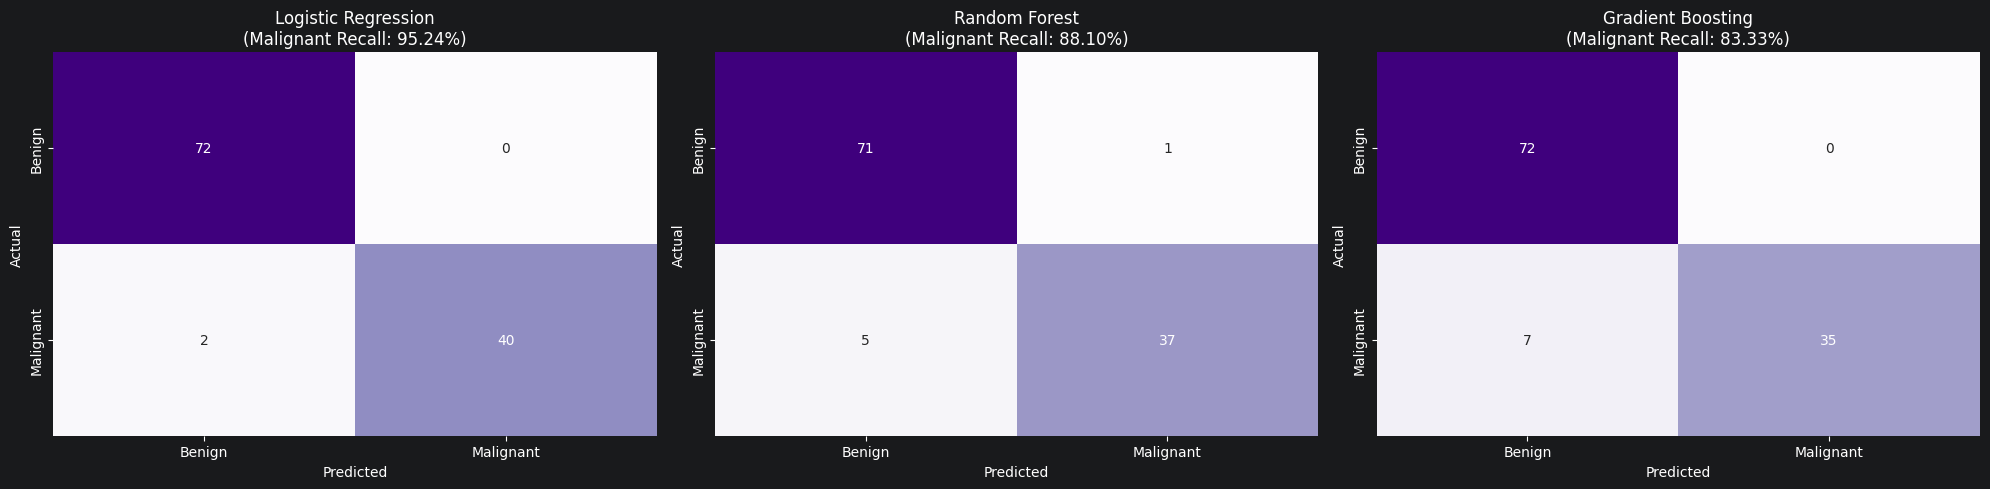

In [27]:

# ==========================================
# 4. PLOT MULTIPLE CONFUSION MATRICES
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Loop through our new models and dynamically plot their matrix layouts
for idx, (name, preds) in enumerate(model_predictions.items()):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
                xticklabels=['Benign', 'Malignant'],
                yticklabels=['Benign', 'Malignant'], ax=axes[idx], cbar=False)

    # Calculate recall specifically to check our medical vulnerability metric
    recall_malignant = cm[1,1] / (cm[1,0] + cm[1,1])

    axes[idx].set_title(f'{name}\n(Malignant Recall: {recall_malignant:.2%})', fontsize=12)
    axes[idx].set_ylabel('Actual')
    axes[idx].set_xlabel('Predicted')

plt.tight_layout()
plt.show()
